# NB15 – Kombinierte Simulation: Hybrid-Dispatch
### CAS Information Engineering – Scripting Project (Kür)
**Gruppe:** SC26_Gruppe_2 | **Datum:** März–Mai 2026

---
Simuliert alle vier Dispatch-Modelle mit denselben Preisdaten und liefert
Visualisierungen für NB05 Business Strategy.

| Modell | Mechanismus |
|--------|------------|
| **Arbitrage-Only** | p25/p75 Dispatch aus NB02 — Referenz |
| **Eigenverbrauch-Only** | NT laden, HT selbst nutzen — kein Einspeisen |
| **Hybrid statisch** | 70% EV-Reserve, 30% Restkapazität Arbitrage |
| **Hybrid optimiert** | Tagesverbrauch-Prognose, optimale Aufteilung |

> Ausgabe: Charts in `output/kuer/<szenario>/` für NB05.

---
| [↑ Projektübersicht](00_Project_Overview.ipynb) | [← NB14 Produktsteckbrief](14_Produkt_Steckbrief.ipynb) | [→ NB05 Business Strategy](05_Business_Strategy.ipynb) |
|:---|:---:|---:|


---
## 0. Setup

In [24]:
# -- Setup ------------------------------------------------------------------
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.filterwarnings("ignore")

with open("config.json") as f:
    CFG = json.load(f)

MODE         = CFG["mode"]
EUR_CHF      = CFG.get("eur_chf", 0.97)
SZ_AKTIV     = CFG["szenarien"]["gleichzeitigkeit_aktiv"]
CHARTS_DIR   = os.path.join("output", "kuer", SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)

_sim          = CFG["pflicht"]["simulation"]
_w            = CFG["pflicht"]["wirtschaftlichkeit"]
CHARGE_Q      = _sim["charge_quantile"]
DISCHARGE_Q   = _sim["discharge_quantile"]
SOC_MIN       = _sim["soc_min_pct"]
SOC_MAX       = _sim["soc_max_pct"]
EFFICIENCY    = _sim["efficiency_roundtrip"]
CAPEX_EUR_KWH = _w["capex_eur_kwh"]
OPEX_RATE     = _w["opex_rate"]
LIFETIME      = _w["lifetime_j"]
ZIEL_ROI      = _w["ziel_roi_pct"]

HT_PREIS = 0.30 * EUR_CHF
NT_PREIS = 0.22 * EUR_CHF

BG_DARK, BG_PANEL = "#0d1117", "#141414"
C_ARB   = "#FFA726"
C_EV    = "#66BB6A"
C_HYB   = "#42A5F5"
C_HYBOP = "#AB47BC"

SEGMENTS = {
    "Privat_10kWh":   {"cap_kwh": 10,    "pow_kw": 5,    "capex_key": "Privat_10kWh"},
    "Gewerbe_100kWh": {"cap_kwh": 100,   "pow_kw": 30,   "capex_key": "Gewerbe_100kWh"},
    "Industrie_1MWh": {"cap_kwh": 1000,  "pow_kw": 200,  "capex_key": "Industrie_1MWh"},
    "Utility_10MWh":  {"cap_kwh": 10000, "pow_kw": 2000, "capex_key": "Utility_10MWh"},
}

print(f"Setup OK | Szenario={SZ_AKTIV} | Charts -> {CHARTS_DIR}")
print(f"EUR_CHF={EUR_CHF} | HT={HT_PREIS:.3f} EUR/kWh | NT={NT_PREIS:.3f} EUR/kWh")


Setup OK | Szenario=realistisch | Charts -> output\kuer\realistisch
EUR_CHF=0.97 | HT=0.291 EUR/kWh | NT=0.213 EUR/kWh


---
## 1. Daten laden

| Datei | Quelle | Inhalt |
|-------|--------|--------|
| `ch_spot_prices_clean.csv` | NB01/NB02 | Stündliche Spot-Preise CH [EUR/MWh] |
| `wirtschaftlichkeit.csv` | NB02 | ROI-Basiswerte Arbitrage-Only |


In [25]:
# -- Preisdaten laden --------------------------------------------------------
DIR_PROC  = os.path.join("data", "processed")
DIR_INTER = os.path.join("data", "intermediate", SZ_AKTIV)

prices_file = os.path.join(DIR_PROC, "ch_spot_prices_clean.csv")
econ_file   = os.path.join(DIR_INTER, "wirtschaftlichkeit.csv")

if os.path.exists(prices_file):
    df_p = pd.read_csv(prices_file, parse_dates=["timestamp"])
    df_p["timestamp"] = pd.to_datetime(df_p["timestamp"], utc=True)
    df_p["hour"]  = df_p["timestamp"].dt.hour
    df_p["month"] = df_p["timestamp"].dt.month
    prices  = df_p["price_eur_mwh"].values
    n_years = len(df_p) / 8760
    hour_arr = df_p["hour"].values
    REAL_DATA = True
    print(f"Preisdaten: {len(df_p):,} Stunden ({n_years:.1f} Jahre)")
    print(f"  Spread (p75-p25): {np.percentile(prices,75)-np.percentile(prices,25):.1f} EUR/MWh")
else:
    print("WARNING: Preisdaten nicht gefunden -- NB01 zuerst ausfuehren.")
    print("  Verwende synthetisches Profil fuer Demonstration.")
    np.random.seed(42)
    n_h = 8760 * 2
    hour_arr = np.tile(np.arange(24), n_h // 24 + 1)[:n_h]
    prices = np.clip(80 + 15*np.sin(2*np.pi*hour_arr/24 - np.pi/2)
                     + 10*np.random.randn(n_h), -50, 300)
    n_years = 2
    REAL_DATA = False

is_nt = (hour_arr >= 20) | (hour_arr < 8)

# Arbitrage-Basiswerte aus NB02
if os.path.exists(econ_file):
    df_econ = pd.read_csv(econ_file)
    ARB_ROI = dict(zip(df_econ["segment"], df_econ["roi_pct"]))
    ARB_NET = dict(zip(df_econ["segment"], df_econ["net_annual"]))
else:
    ARB_ROI = {"Privat_10kWh": 0.6, "Gewerbe_100kWh": 1.4,
               "Industrie_1MWh": 2.3, "Utility_10MWh": 1.3}
    ARB_NET = {k: SEGMENTS[k]["cap_kwh"]*CAPEX_EUR_KWH[SEGMENTS[k]["capex_key"]]*v/100
               for k, v in ARB_ROI.items()}
    print("  Fallback: ROI-Werte aus NB02-Output")

print(f"Arbitrage-Only ROI: { {k: f'{v:.1f}%' for k,v in ARB_ROI.items()} }")


Preisdaten: 28,392 Stunden (3.2 Jahre)
  Spread (p75-p25): 47.5 EUR/MWh
Arbitrage-Only ROI: {'Privat_10kWh': '0.6%', 'Gewerbe_100kWh': '1.4%', 'Industrie_1MWh': '2.3%', 'Utility_10MWh': '1.3%'}


---
## 2. Hybrid-Dispatch Simulation

### Dispatch-Logik

```
Arbitrage-Only:   Laden bei Preis < p25(Tag), Einspeisen bei Preis > p75(Tag)
Eigenverbrauch:   NT laden (20-08h + WE), HT selbst nutzen -- kein Einspeisen
Hybrid statisch:  EV_FRAC x Kapazitaet reserviert fuer EV; Rest fuer Arbitrage
Hybrid optimiert: EV_FRAC taeglich angepasst basierend auf Spread-Niveau
```


In [26]:
# -- Simulationsfunktionen -------------------------------------------------
EV_FRAC_STATIC  = 0.70   # Anteil Kapazitaet fuer EV reserviert
VERBRAUCH_TAG   = 10.0   # kWh/Tag (Privat-Referenz)

def sim_arbitrage(prices, cap_kwh, pow_kw, n_years):
    """p25/p75 Tagesquantil-Dispatch identisch NB02"""
    n = len(prices); soc = 0.5; revenue = 0.0
    for d in range(n // 24):
        dp = prices[d*24:(d+1)*24]
        pL = np.percentile(dp, CHARGE_Q*100)
        pH = np.percentile(dp, DISCHARGE_Q*100)
        for h in range(24):
            idx = d*24 + h; price = prices[idx]
            mxC = min(pow_kw, (SOC_MAX-soc)*cap_kwh/EFFICIENCY)
            mxD = min(pow_kw, (soc-SOC_MIN)*cap_kwh)
            if price <= pL and soc < SOC_MAX and mxC > 0:
                e = min(mxC, pow_kw); soc += e*EFFICIENCY/cap_kwh
                revenue -= e*price/1000
            elif price >= pH and soc > SOC_MIN and mxD > 0:
                e = min(mxD, pow_kw); soc -= e/cap_kwh
                revenue += e*price/1000
    return revenue / n_years

def sim_ev(cap_kwh, pow_kw, verbrauch_j, n_years):
    """NT laden (nur was HT-Bedarf erfordert), HT Eigenverbrauch."""
    n = len(is_nt); soc = 0.5; total = 0.0
    v_h = verbrauch_j / (365*n_years*24)
    # Maximaler Tagesbedarf HT (12h Fenster)
    v_day_ht = min(12*v_h, (SOC_MAX-SOC_MIN)*cap_kwh)
    for d in range(n // 24):
        soc_target = min(SOC_MAX, SOC_MIN + v_day_ht/cap_kwh)
        for h in range(24):
            idx = d*24 + h; nt = is_nt[idx]
            if nt and soc < soc_target:
                e = min(pow_kw, (soc_target-soc)*cap_kwh/EFFICIENCY)
                soc += e*EFFICIENCY/cap_kwh; total -= e*NT_PREIS
            elif not nt and soc > SOC_MIN:
                bed = min(v_h, (soc-SOC_MIN)*cap_kwh)
                soc -= bed/cap_kwh; total += bed*HT_PREIS
    return total / n_years

def sim_hybrid(prices, cap_kwh, pow_kw, verbrauch_j, n_years, optimized=False):
    """Zwei virtuelle Partitionen:
    - EV-Partition  (cap_kwh * frac):       Haushalt-Tarife NT/HT
    - Arb-Partition (cap_kwh * (1-frac)):   Spot-Preise p25/p75
    Jede Partition hat eigenen SOC [SOC_MIN..SOC_MAX].
    """
    n = len(prices); v_h = verbrauch_j / (365*n_years*24)
    soc_ev = 0.5; soc_arb = 0.5; total = 0.0
    for d in range(n // 24):
        dp = prices[d*24:(d+1)*24]
        pL = np.percentile(dp, CHARGE_Q*100)
        pH = np.percentile(dp, DISCHARGE_Q*100)
        spread = pH - pL
        if optimized:
            frac = float(np.clip(0.80 - (spread-20)/300, 0.40, 0.85))
        else:
            frac = EV_FRAC_STATIC
        cap_ev  = cap_kwh * frac;       cap_arb = cap_kwh * (1-frac)
        pow_ev  = pow_kw  * frac;       pow_arb = pow_kw  * (1-frac)
        v_day_ht = min(12*v_h, (SOC_MAX-SOC_MIN)*cap_ev) if cap_ev > 0 else 0
        soc_ev_target = min(SOC_MAX, SOC_MIN + v_day_ht/cap_ev) if cap_ev > 0 else SOC_MAX
        for h in range(24):
            idx = d*24 + h; price = prices[idx]
            nt = is_nt[idx % len(is_nt)]
            # EV-Partition: Haushalt-Tarif
            if cap_ev > 0:
                if nt and soc_ev < soc_ev_target:
                    e = min(pow_ev, (soc_ev_target-soc_ev)*cap_ev/EFFICIENCY)
                    soc_ev += e*EFFICIENCY/cap_ev; total -= e*NT_PREIS
                elif not nt and soc_ev > SOC_MIN:
                    bed = min(v_h, (soc_ev-SOC_MIN)*cap_ev)
                    soc_ev -= bed/cap_ev; total += bed*HT_PREIS
            # Arb-Partition: Spot-Preise
            if cap_arb > 0:
                mxC = min(pow_arb, (SOC_MAX-soc_arb)*cap_arb/EFFICIENCY)
                mxD = min(pow_arb, (soc_arb-SOC_MIN)*cap_arb)
                if price <= pL and soc_arb < SOC_MAX and mxC > 0:
                    e = min(mxC, pow_arb); soc_arb += e*EFFICIENCY/cap_arb
                    total -= e*price/1000
                elif price >= pH and soc_arb > SOC_MIN and mxD > 0:
                    e = min(mxD, pow_arb); soc_arb -= e/cap_arb
                    total += e*price/1000
    return total / n_years

# -- Alle Segmente simulieren -------------------------------------------------
results = {}
for seg, p in SEGMENTS.items():
    cap  = p["cap_kwh"]; pow_ = p["pow_kw"]
    capex = cap * CAPEX_EUR_KWH[p["capex_key"]]
    opex  = capex * OPEX_RATE
    verbrauch = VERBRAUCH_TAG * 365 * n_years * (cap/10)**0.55
    arb   = sim_arbitrage(prices, cap, pow_, n_years)
    ev    = sim_ev(cap, pow_, verbrauch, n_years)
    hyb   = sim_hybrid(prices, cap, pow_, verbrauch, n_years, False)
    hybo  = sim_hybrid(prices, cap, pow_, verbrauch, n_years, True)
    def roi(net): return (net-opex)/capex*100 if capex>0 else 0
    def be(net): n=net-opex; return capex/n if n>0 else float("inf")
    results[seg] = dict(capex=capex, opex=opex,
        arb_j=arb, ev_j=ev, hyb_j=hyb, hybo_j=hybo,
        roi_arb=roi(arb), roi_ev=roi(ev), roi_hyb=roi(hyb), roi_hybo=roi(hybo),
        be_arb=be(arb), be_ev=be(ev), be_hyb=be(hyb), be_hybo=be(hybo))

def fmt_be(v, lim=30): return f">{lim}J" if v > lim else f"{v:.0f}J"

print(f"{'Segment':<22} {'Arb':>7} {'EV':>7} {'Hyb':>7} {'Hyb-Opt':>9}  "
      f"{'BE-Arb':>8} {'BE-Hyb':>8} {'BE-Opt':>8}")
print("-"*88)
for seg, r in results.items():
    print(f"{seg:<22} {r['roi_arb']:>6.1f}% {r['roi_ev']:>6.1f}% "
          f"{r['roi_hyb']:>6.1f}% {r['roi_hybo']:>8.1f}%  "
          f"{fmt_be(r['be_arb']):>8} {fmt_be(r['be_hyb']):>8} {fmt_be(r['be_hybo']):>8}")


Segment                    Arb      EV     Hyb   Hyb-Opt    BE-Arb   BE-Hyb   BE-Opt
----------------------------------------------------------------------------------------
Privat_10kWh              2.1%    1.2%    2.3%      2.2%      >30J     >30J     >30J
Gewerbe_100kWh            3.6%   -0.2%    1.3%      1.2%       28J     >30J     >30J
Industrie_1MWh            5.2%   -0.9%    1.1%      0.9%       19J     >30J     >30J
Utility_10MWh             6.6%   -1.2%    1.2%      1.0%       15J     >30J     >30J


---
## 3. Visualisierungen für NB05

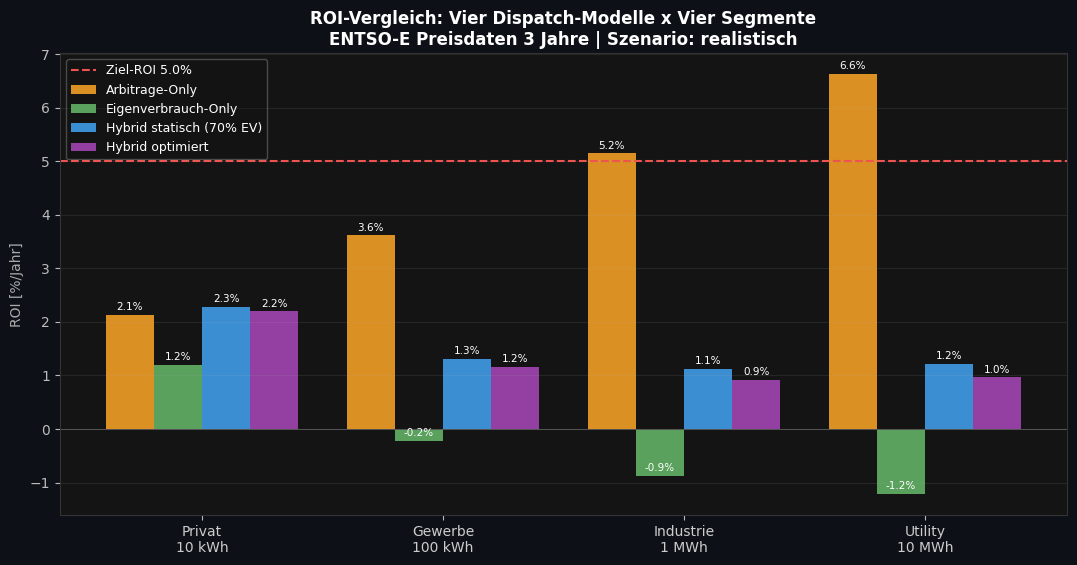

Gespeichert: output\kuer\realistisch\nb15_roi_vergleich.png


In [27]:
# -- Chart nb15_roi_vergleich ------------------------------------------------
segs   = list(results.keys())
labels = ["Privat\n10 kWh","Gewerbe\n100 kWh","Industrie\n1 MWh","Utility\n10 MWh"]
models = [("roi_arb","Arbitrage-Only",C_ARB),
          ("roi_ev","Eigenverbrauch-Only",C_EV),
          (f"roi_hyb",f"Hybrid statisch ({EV_FRAC_STATIC:.0%} EV)",C_HYB),
          ("roi_hybo","Hybrid optimiert",C_HYBOP)]
x = np.arange(len(segs)); w = 0.2

fig, ax = plt.subplots(figsize=(13,6))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors="#bbbbbb")
for sp in ax.spines.values(): sp.set_edgecolor("#333")

for j,(key,label,col) in enumerate(models):
    vals = [results[s][key] for s in segs]
    bars = ax.bar(x+j*w-1.5*w, vals, w, label=label, color=col, alpha=0.85)
    for bar,v in zip(bars,vals):
        if abs(v)>0.05:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f"{v:.1f}%", ha="center", va="bottom", color="white", fontsize=7.5)

ax.axhline(ZIEL_ROI, color="#EF5350", lw=1.5, ls="--", label=f"Ziel-ROI {ZIEL_ROI}%")
ax.axhline(0, color="#555", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(labels, color="#ccc")
ax.set_ylabel("ROI [%/Jahr]", color="#aaa")
ax.set_title("ROI-Vergleich: Vier Dispatch-Modelle x Vier Segmente\n"
             f"ENTSO-E Preisdaten {int(n_years)} Jahre | Szenario: {SZ_AKTIV}",
             color="white", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.3, facecolor="#111", labelcolor="white")
ax.grid(True, axis="y", alpha=0.12)
p = os.path.join(CHARTS_DIR,"nb15_roi_vergleich.png")
plt.savefig(p, dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


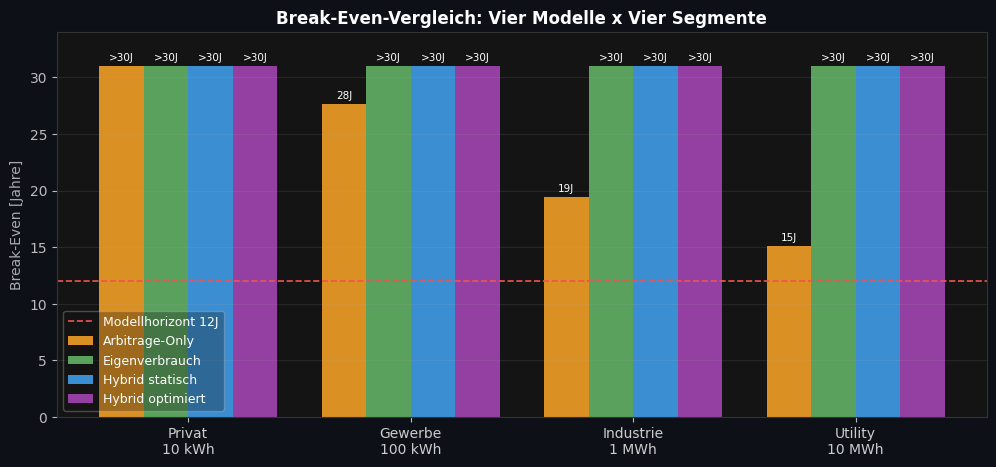

Gespeichert: output\kuer\realistisch\nb15_breakeven_vergleich.png


In [28]:
# -- Chart nb15_breakeven_vergleich ------------------------------------------
DMAX = 30
fig, ax = plt.subplots(figsize=(12,5))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors="#bbbbbb")
for sp in ax.spines.values(): sp.set_edgecolor("#333")

for j,(key,label,col) in enumerate([("be_arb","Arbitrage-Only",C_ARB),
    ("be_ev","Eigenverbrauch",C_EV),("be_hyb","Hybrid statisch",C_HYB),
    ("be_hybo","Hybrid optimiert",C_HYBOP)]):
    vals = [min(results[s][key],DMAX+1) for s in segs]
    bars = ax.bar(x+j*w-1.5*w, vals, w, label=label, color=col, alpha=0.85)
    for bar,s in zip(bars,segs):
        v = results[s][key]
        txt = f">{DMAX}J" if v>DMAX else f"{v:.0f}J"
        ax.text(bar.get_x()+bar.get_width()/2, min(v,DMAX+1)+0.3,
                txt, ha="center", va="bottom", color="white", fontsize=7.5)

ax.axhline(LIFETIME, color="#EF5350", lw=1.2, ls="--",
           label=f"Modellhorizont {LIFETIME}J")
ax.set_xticks(x); ax.set_xticklabels(labels, color="#ccc")
ax.set_ylabel("Break-Even [Jahre]", color="#aaa")
ax.set_ylim(0, DMAX+4)
ax.set_title("Break-Even-Vergleich: Vier Modelle x Vier Segmente",
             color="white", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.3, facecolor="#111", labelcolor="white")
ax.grid(True, axis="y", alpha=0.12)
p = os.path.join(CHARTS_DIR,"nb15_breakeven_vergleich.png")
plt.savefig(p, dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


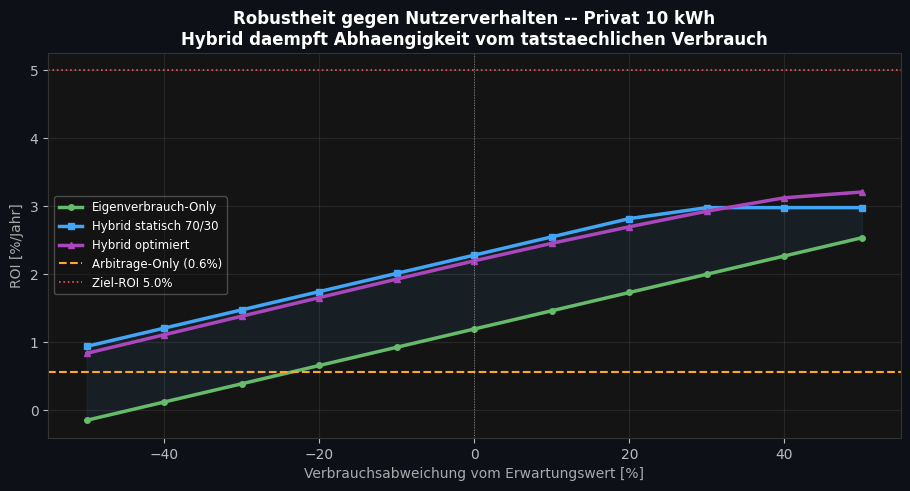

Gespeichert: output\kuer\realistisch\nb15_nutzerverhalten_sensitivity.png


In [29]:
# -- Chart nb15_nutzerverhalten_sensitivity -----------------------------------
seg="Privat_10kWh"; cap=SEGMENTS[seg]["cap_kwh"]; pow_=SEGMENTS[seg]["pow_kw"]
capex=cap*CAPEX_EUR_KWH[SEGMENTS[seg]["capex_key"]]; opex=capex*OPEX_RATE
vbasis = VERBRAUCH_TAG*365*n_years
abw = np.linspace(0.5, 1.5, 11)
roi_ev_l, roi_hyb_l, roi_hybo_l = [], [], []
for fac in abw:
    v = vbasis*fac
    roi_ev_l.append((sim_ev(cap,pow_,v,n_years)-opex)/capex*100)
    roi_hyb_l.append((sim_hybrid(prices,cap,pow_,v,n_years,False)-opex)/capex*100)
    roi_hybo_l.append((sim_hybrid(prices,cap,pow_,v,n_years,True)-opex)/capex*100)

fig, ax = plt.subplots(figsize=(11,5))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors="#bbbbbb")
for sp in ax.spines.values(): sp.set_edgecolor("#333")
pct = (abw-1)*100
ax.plot(pct, roi_ev_l,   color=C_EV,    lw=2.5, label="Eigenverbrauch-Only",       marker="o", ms=4)
ax.plot(pct, roi_hyb_l,  color=C_HYB,   lw=2.5, label="Hybrid statisch 70/30",     marker="s", ms=4)
ax.plot(pct, roi_hybo_l, color=C_HYBOP, lw=2.5, label="Hybrid optimiert",           marker="^", ms=4)
ax.axhline(ARB_ROI[seg], color=C_ARB, lw=1.5, ls="--",
           label=f"Arbitrage-Only ({ARB_ROI[seg]:.1f}%)")
ax.axhline(ZIEL_ROI, color="#EF5350", lw=1.2, ls=":", label=f"Ziel-ROI {ZIEL_ROI}%")
ax.axvline(0, color="white", lw=0.7, ls=":", alpha=0.4)
ax.fill_between(pct, roi_hyb_l, roi_ev_l, alpha=0.08, color=C_HYB)
ax.set_xlabel("Verbrauchsabweichung vom Erwartungswert [%]", color="#aaa")
ax.set_ylabel("ROI [%/Jahr]", color="#aaa")
ax.set_title("Robustheit gegen Nutzerverhalten -- Privat 10 kWh\n"
             "Hybrid daempft Abhaengigkeit vom tatstaechlichen Verbrauch",
             color="white", fontweight="bold")
ax.legend(fontsize=8.5, framealpha=0.3, facecolor="#111", labelcolor="white")
ax.grid(True, alpha=0.12)
p = os.path.join(CHARTS_DIR,"nb15_nutzerverhalten_sensitivity.png")
plt.savefig(p, dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


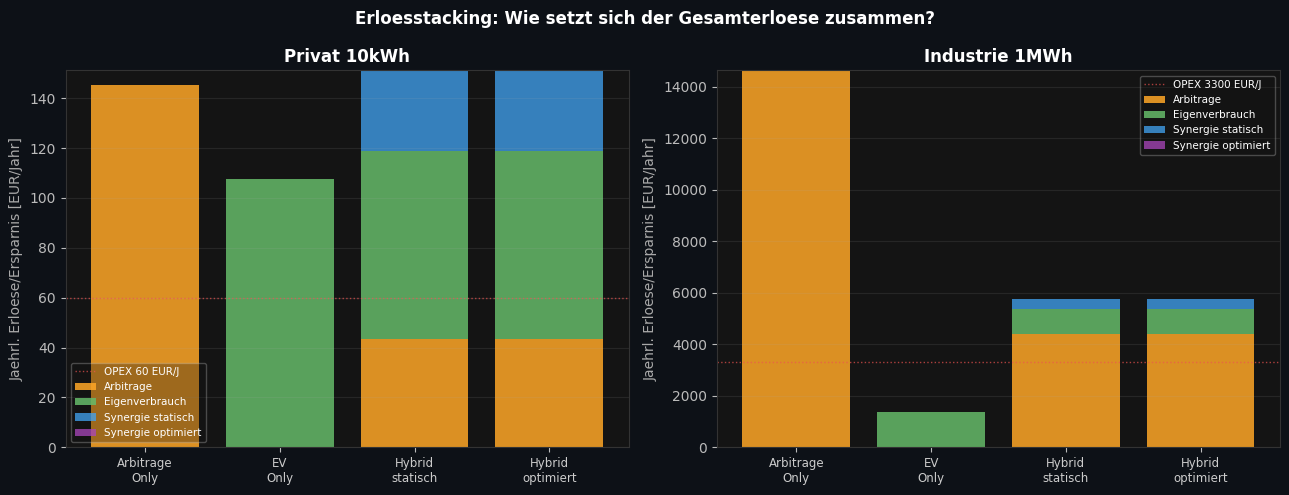

Gespeichert: output\kuer\realistisch\nb15_revenue_split.png


In [30]:
# -- Chart nb15_revenue_split -------------------------------------------------
fig, axes = plt.subplots(1,2, figsize=(13,5))
fig.patch.set_facecolor(BG_DARK)
for ax, seg_key in zip(axes, ["Privat_10kWh","Industrie_1MWh"]):
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors="#bbbbbb")
    for sp in ax.spines.values(): sp.set_edgecolor("#333")
    p2 = SEGMENTS[seg_key]
    cap2,pow2 = p2["cap_kwh"],p2["pow_kw"]
    capex2 = cap2*CAPEX_EUR_KWH[p2["capex_key"]]; opex2=capex2*OPEX_RATE
    r = results[seg_key]
    arb_share  = r["arb_j"] * (1-EV_FRAC_STATIC)
    ev_share   = r["ev_j"]  * EV_FRAC_STATIC
    syn_static = max(0, r["hyb_j"] - arb_share - ev_share)
    syn_opt    = max(0, r["hybo_j"]- arb_share - ev_share - syn_static)
    mnames = ["Arbitrage\nOnly","EV\nOnly","Hybrid\nstatisch","Hybrid\noptimiert"]
    avs = [r["arb_j"], 0, arb_share, arb_share]
    evs = [0, r["ev_j"], ev_share, ev_share]
    sys1= [0, 0, syn_static, syn_static]
    sys2= [0, 0, 0, syn_opt]
    xp = np.arange(4)
    ax.bar(xp, avs, color=C_ARB, alpha=0.85, label="Arbitrage")
    ax.bar(xp, evs, bottom=avs, color=C_EV, alpha=0.85, label="Eigenverbrauch")
    b2=[a+e for a,e in zip(avs,evs)]
    ax.bar(xp, sys1, bottom=b2, color=C_HYB, alpha=0.75, label="Synergie statisch")
    b3=[a+b for a,b in zip(b2,sys1)]
    ax.bar(xp, sys2, bottom=b3, color=C_HYBOP, alpha=0.75, label="Synergie optimiert")
    ax.axhline(opex2, color="#EF5350", lw=1, ls=":", alpha=0.7,
               label=f"OPEX {opex2:.0f} EUR/J")
    ax.set_xticks(xp); ax.set_xticklabels(mnames, fontsize=8.5, color="#ccc")
    ax.set_ylabel("Jaehrl. Erloese/Ersparnis [EUR/Jahr]", color="#aaa")
    ax.set_title(seg_key.replace("_"," "), color="white", fontweight="bold")
    ax.legend(fontsize=7.5, framealpha=0.3, facecolor="#111", labelcolor="white")
    ax.grid(True, axis="y", alpha=0.12)
plt.suptitle("Erloesstacking: Wie setzt sich der Gesamterloese zusammen?",
             color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
p = os.path.join(CHARTS_DIR,"nb15_revenue_split.png")
plt.savefig(p, dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


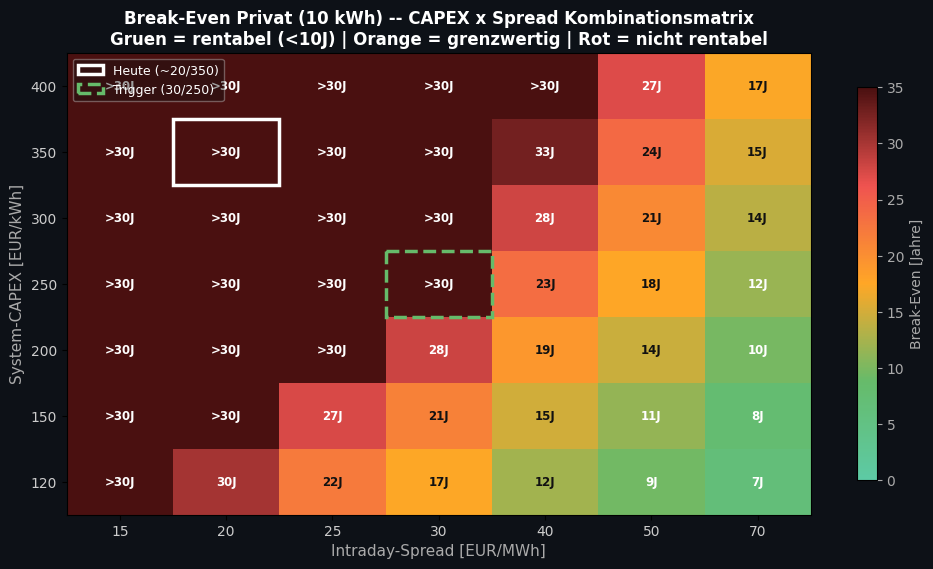

Gespeichert: output\kuer\realistisch\nb15_kombi_heatmap.png


In [31]:
# -- Chart nb15_kombi_heatmap -------------------------------------------------
spreads_h = [15,20,25,30,40,50,70]
capexes_h = [400,350,300,250,200,150,120]
CAP_K=10; OPX=OPEX_RATE
ref_n=83; ref_s=20; ref_c=400  # NB02 Privat Netto/Jahr

def be_est(spr, cap):
    capex2=cap*CAP_K; opex2=capex2*OPX
    n=ref_n*(spr/ref_s)*(cap/ref_c)**0.3
    net=n-opex2; return capex2/net if net>0 else 40

matrix = np.array([[min(be_est(s,c),38) for s in spreads_h] for c in capexes_h])

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
cmap = mcolors.LinearSegmentedColormap.from_list("",["#5DCAA5","#66BB6A","#FFA726","#EF5350","#4a1010"])
im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=35, aspect="auto")

for i in range(len(capexes_h)):
    for j in range(len(spreads_h)):
        v=matrix[i,j]
        txt=">30J" if v>=35 else f"{v:.0f}J"
        col="white" if v<12 or v>26 else "#111"
        ax.text(j,i,txt,ha="center",va="center",fontsize=8.5,color=col,fontweight="bold")

ax.set_xticks(range(len(spreads_h)))
ax.set_xticklabels([str(s) for s in spreads_h], color="#ccc")
ax.set_yticks(range(len(capexes_h)))
ax.set_yticklabels([str(c) for c in capexes_h], color="#ccc")
ax.set_xlabel("Intraday-Spread [EUR/MWh]", color="#aaa", fontsize=11)
ax.set_ylabel("System-CAPEX [EUR/kWh]", color="#aaa", fontsize=11)
ax.set_title("Break-Even Privat (10 kWh) -- CAPEX x Spread Kombinationsmatrix\n"
             "Gruen = rentabel (<10J) | Orange = grenzwertig | Rot = nicht rentabel",
             color="white", fontweight="bold")
# Heute
ts=spreads_h.index(min(spreads_h,key=lambda x:abs(x-20)))
tc=capexes_h.index(min(capexes_h,key=lambda x:abs(x-350)))
ax.add_patch(plt.Rectangle((ts-0.5,tc-0.5),1,1,fill=False,edgecolor="white",lw=2.5,label="Heute (~20/350)"))
tr_s=spreads_h.index(min(spreads_h,key=lambda x:abs(x-30)))
tr_c=capexes_h.index(min(capexes_h,key=lambda x:abs(x-250)))
ax.add_patch(plt.Rectangle((tr_s-0.5,tr_c-0.5),1,1,fill=False,edgecolor="#66BB6A",lw=2.5,ls="--",label="Trigger (30/250)"))
cb=plt.colorbar(im,ax=ax,label="Break-Even [Jahre]",shrink=0.85)
cb.ax.tick_params(colors="#aaa"); cb.ax.yaxis.label.set_color("#aaa")
ax.legend(fontsize=9,framealpha=0.4,facecolor="#111",labelcolor="white",loc="upper left")
p=os.path.join(CHARTS_DIR,"nb15_kombi_heatmap.png")
plt.savefig(p,dpi=150,bbox_inches="tight",facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


---
## 4. CAPEX-Szenarien: Was bringt sinkender Systempreis?

Dieselbe Hybrid-Simulation mit drei CAPEX-Niveaus:

| Szenario | CAPEX Privat | Bedeutung | Quelle |
|----------|-------------|-----------|--------|
| **Heute** | 400 EUR/kWh | 2023-2025 Markt CH | NB02/config.json |
| **Trigger** | 250 EUR/kWh | Monitoring-Schwelle | `kuer.markt.capex_ziel_privat_eur_kwh` |
| **Ziel** | 150 EUR/kWh | ~2030 NREL ATB Advanced | NB11 Projektion |

> CAPEX-Trigger aus `config.json` (SSOT) -- nicht hardcoded.


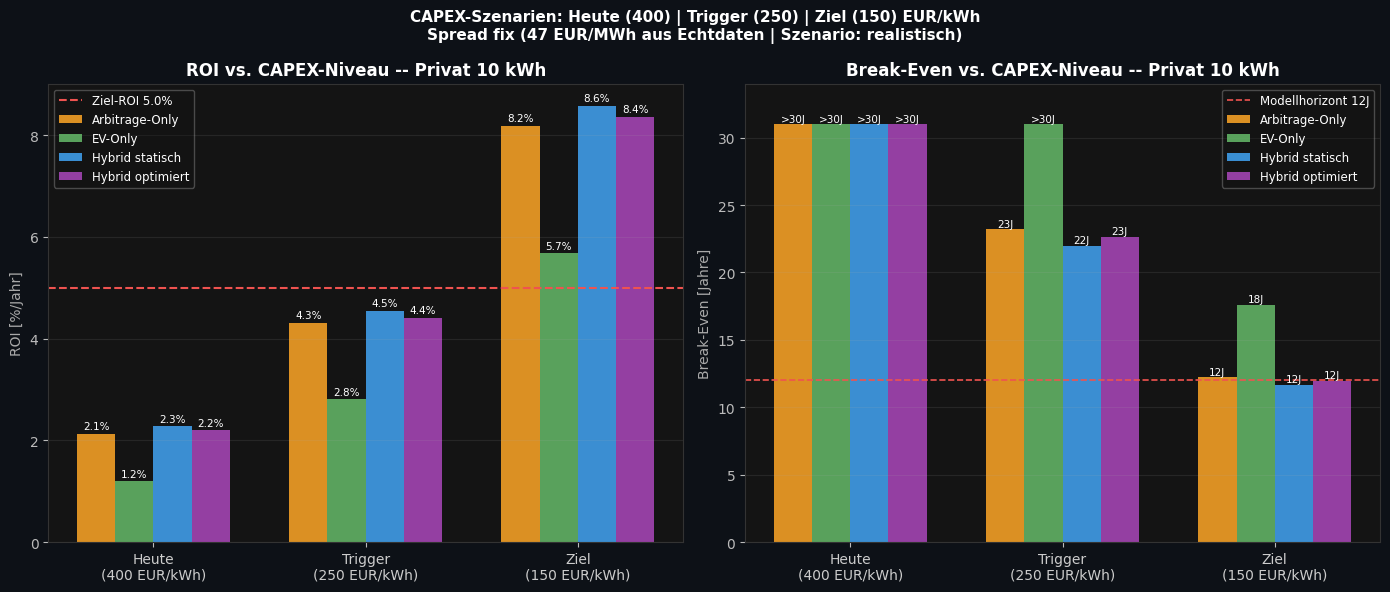

Gespeichert: output\kuer\realistisch\nb15_capex_szenarien.png
CAPEX-Trigger aus config.json: 250 EUR/kWh
Modell                      Heute    Trigger     Ziel  (ROI %/J)
-------------------------------------------------------
Arbitrage-Only               2.1%       4.3%     8.2%
EV-Only                      1.2%       2.8%     5.7%
Hybrid statisch              2.3%       4.5%     8.6%
Hybrid optimiert             2.2%       4.4%     8.4%


In [32]:
# -- Chart nb15_capex_szenarien: ROI und Break-Even vs. CAPEX-Niveau --------
CAPEX_TRIGGER = CFG.get('kuer', {}).get('markt', {}).get('capex_ziel_privat_eur_kwh', 250)
CAPEX_SZ = {'Heute\n(400 EUR/kWh)': 400,
            f'Trigger\n({CAPEX_TRIGGER} EUR/kWh)': CAPEX_TRIGGER,
            'Ziel\n(150 EUR/kWh)': 150}

seg = 'Privat_10kWh'
cap = SEGMENTS[seg]['cap_kwh']; pow_ = SEGMENTS[seg]['pow_kw']
verbrauch = VERBRAUCH_TAG * 365 * n_years

arb_j  = sim_arbitrage(prices, cap, pow_, n_years)
ev_j   = sim_ev(cap, pow_, verbrauch, n_years)
hyb_j  = sim_hybrid(prices, cap, pow_, verbrauch, n_years, False)
hybo_j = sim_hybrid(prices, cap, pow_, verbrauch, n_years, True)

models_c = [('Arbitrage-Only', arb_j, C_ARB), ('EV-Only', ev_j, C_EV),
            ('Hybrid statisch', hyb_j, C_HYB), ('Hybrid optimiert', hybo_j, C_HYBOP)]
capex_labels = list(CAPEX_SZ.keys())
capex_vals   = list(CAPEX_SZ.values())
x = np.arange(len(capex_vals)); w = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_DARK)
DMAX2 = 30

for ax_idx, (ax, mode) in enumerate(zip(axes, ['roi', 'be'])):
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    for j, (label, net_j, col) in enumerate(models_c):
        vals = []
        for cv in capex_vals:
            capex2 = cap * cv; opex2 = capex2 * OPEX_RATE; netto = net_j - opex2
            if mode == 'roi':
                vals.append(netto / capex2 * 100 if capex2 > 0 else 0)
            else:
                vals.append(min(capex2 / netto if netto > 0 else DMAX2+1, DMAX2+1))
        bars = ax.bar(x + j*w - 1.5*w, vals, w, label=label, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            disp = f'{v:.1f}%' if mode=='roi' else (f'>{DMAX2}J' if v>=DMAX2 else f'{v:.0f}J')
            if abs(v) > 0.05:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                        disp, ha='center', va='bottom', color='white', fontsize=7.5)
    if mode == 'roi':
        ax.axhline(ZIEL_ROI, color='#EF5350', lw=1.5, ls='--', label=f'Ziel-ROI {ZIEL_ROI}%')
        ax.axhline(0, color='#555', lw=0.7)
        ax.set_ylabel('ROI [%/Jahr]', color='#aaa')
        ax.set_title('ROI vs. CAPEX-Niveau -- Privat 10 kWh', color='white', fontweight='bold')
    else:
        ax.axhline(LIFETIME, color='#EF5350', lw=1.2, ls='--', label=f'Modellhorizont {LIFETIME}J')
        ax.set_ylim(0, DMAX2+4)
        ax.set_ylabel('Break-Even [Jahre]', color='#aaa')
        ax.set_title('Break-Even vs. CAPEX-Niveau -- Privat 10 kWh', color='white', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(capex_labels, color='#ccc')
    ax.legend(fontsize=8.5, framealpha=0.3, facecolor='#111', labelcolor='white')
    ax.grid(True, axis='y', alpha=0.12)

spread_actual = np.percentile(prices,75)-np.percentile(prices,25)
plt.suptitle(f'CAPEX-Szenarien: Heute ({400}) | Trigger ({CAPEX_TRIGGER}) | Ziel (150) EUR/kWh'
             f'\nSpread fix ({spread_actual:.0f} EUR/MWh aus Echtdaten | Szenario: {SZ_AKTIV})',
             color='white', fontsize=11, fontweight='bold')
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb15_capex_szenarien.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'Gespeichert: {p}')
print(f'CAPEX-Trigger aus config.json: {CAPEX_TRIGGER} EUR/kWh')
print(f"{'Modell':<22} {'Heute':>10} {'Trigger':>10} {'Ziel':>8}  (ROI %/J)")
print('-'*55)
for label, net_j, _ in models_c:
    def roi2(cv): n=net_j-cap*cv*OPEX_RATE; return n/(cap*cv)*100
    print(f"{label:<22} {roi2(400):>9.1f}% {roi2(CAPEX_TRIGGER):>9.1f}% {roi2(150):>7.1f}%")


---
## 4. Abschlusskontrolle & NB05-Referenz

| Chart | NB05-Sektion | `show()`-Aufruf |
|-------|-------------|------------------|
| `nb15_roi_vergleich.png` | 3. Segmentstrategie | `show('nb15_roi_vergleich.png', ...)` |
| `nb15_breakeven_vergleich.png` | 3. Segmentstrategie | `show('nb15_breakeven_vergleich.png', ...)` |
| `nb15_nutzerverhalten_sensitivity.png` | 3. Segmentstrategie | `show('nb15_nutzerverhalten_sensitivity.png', ...)` |
| `nb15_revenue_split.png` | 7. VPP | `show('nb15_revenue_split.png', ...)` |
| `nb15_kombi_heatmap.png` | 10. Kombinationsmatrix | `show('nb15_kombi_heatmap.png', ...)` |

| `nb15_capex_szenarien.png` | 8. VPP + 10. Kombinationsmatrix | `show('nb15_capex_szenarien.png', ...)` |

> **Ausführungsreihenfolge:** NB01 → NB02 → NB03 → **NB15** → NB05


In [33]:
# -- Abschlusskontrolle -------------------------------------------------------
expected = ["nb15_roi_vergleich.png","nb15_breakeven_vergleich.png",
            "nb15_nutzerverhalten_sensitivity.png",
            "nb15_revenue_split.png","nb15_kombi_heatmap.png",
            "nb15_capex_szenarien.png"]
print("=== Abschlusskontrolle NB15 ===")
all_ok = True
for fn in expected:
    path = os.path.join(CHARTS_DIR, fn)
    ok = os.path.exists(path)
    print(f"  {'OK' if ok else 'FEHLT'}  {fn}")
    if not ok: all_ok = False
print(f"\n{'Alle Charts bereit' if all_ok else 'Fehlende Charts -- Zellen neu ausfuehren'}")
print(f"\nROI-Zusammenfassung:")
print(f"{'Segment':<22} {'Arb':>7} {'EV':>7} {'Hyb':>7} {'Hyb-Opt':>9}")
print("-"*58)
for seg,r in results.items():
    print(f"{seg:<22} {r['roi_arb']:>6.1f}% {r['roi_ev']:>6.1f}% "
          f"{r['roi_hyb']:>6.1f}% {r['roi_hybo']:>8.1f}%")


=== Abschlusskontrolle NB15 ===
  OK  nb15_roi_vergleich.png
  OK  nb15_breakeven_vergleich.png
  OK  nb15_nutzerverhalten_sensitivity.png
  OK  nb15_revenue_split.png
  OK  nb15_kombi_heatmap.png
  OK  nb15_capex_szenarien.png

Alle Charts bereit

ROI-Zusammenfassung:
Segment                    Arb      EV     Hyb   Hyb-Opt
----------------------------------------------------------
Privat_10kWh              2.1%    1.2%    2.3%      2.2%
Gewerbe_100kWh            3.6%   -0.2%    1.3%      1.2%
Industrie_1MWh            5.2%   -0.9%    1.1%      0.9%
Utility_10MWh             6.6%   -1.2%    1.2%      1.0%


---
| [↑ Projektübersicht](00_Project_Overview.ipynb) | [← NB14 Produktsteckbrief](14_Produkt_Steckbrief.ipynb) | [→ NB05 Business Strategy](05_Business_Strategy.ipynb) |
|:---|:---:|---:|
